# Cross-Sectional Regression
Build regression dataset, fit OLS, run diagnostics.

C:\Python 3.7\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
C:\Python 3.7\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
C:\Python 3.7\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 6
  warnings.warn('covariance of constraints does not have full '
C:\Python 3.7\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


                            OLS Regression Results                            
Dep. Variable:                    CAR   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     176.6
Date:                Mon, 10 Aug 2026   Prob (F-statistic):          3.95e-193
Time:                        21:34:53   Log-Likelihood:                 4272.5
No. Observations:                3037   AIC:                            -8531.
Df Residuals:                    3030   BIC:                            -8489.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.3523    

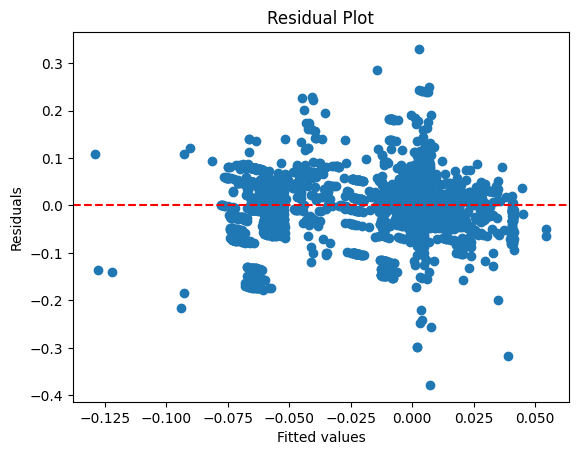

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load Data
events_df = pd.read_csv('../data/processed/events_with_car.csv')
mc_df = pd.read_csv('../data/processed/market_caps.csv')
events_df = events_df.merge(mc_df, left_on='ISSUERTRADINGSYMBOL', right_on='Ticker', how='left')

# Prepare Variables
events_df['LogTransactionValue'] = np.log(events_df['TransactionValue'])
events_df['LogFirmSize'] = np.log(events_df['MarketCap'].replace(0, np.nan))

events_df['BuyDummy'] = (events_df['TRANS_CODE'] == 'P').astype(int)
events_df['Interaction'] = events_df['BuyDummy'] * events_df['LogFirmSize']

# Dummy for Insider Role
rel = events_df['RPTOWNER_RELATIONSHIP'].fillna('')
events_df['IsCEO'] = rel.str.contains('CEO', case=False).astype(int)
events_df['IsCFO'] = rel.str.contains('CFO', case=False).astype(int)
events_df['IsDirector'] = rel.str.contains('Director', case=False).astype(int)
events_df['Is10pctOwner'] = rel.str.contains('10%', case=False).astype(int)
events_df['IsOtherOfficer'] = (rel.str.contains('Officer', case=False) & ~rel.str.contains('CEO|CFO', case=False)).astype(int)

# Regression Dataset
cols = ['CAR', 'LogTransactionValue', 'LogFirmSize', 'BuyDummy', 'Interaction', 
        'IsCEO', 'IsCFO', 'IsDirector', 'Is10pctOwner', 'IsOtherOfficer']
reg_data = events_df[cols].dropna()

X = reg_data[['LogTransactionValue', 'LogFirmSize', 'BuyDummy', 'Interaction', 
              'IsCEO', 'IsCFO', 'IsDirector', 'Is10pctOwner', 'IsOtherOfficer']]
X = sm.add_constant(X)
y = reg_data['CAR']

# Fit OLS
model = sm.OLS(y, X).fit()
print(model.summary())

# Diagnostics
# Heteroskedasticity (Breusch-Pagan)
try:
    bp_test = het_breuschpagan(model.resid, model.model.exog)
    print(f"\nBreusch-Pagan p-value: {bp_test[1]}")
    
    if bp_test[1] < 0.05:
        print("Heteroskedasticity detected. Using White/HC3 robust standard errors.")
        robust_model = sm.OLS(y, X).fit(cov_type='HC3')
        print(robust_model.summary())
except Exception as e:
    print(f"Could not run Breusch-Pagan test: {e}")

# Multicollinearity (VIF)
try:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    print(vif_data)
except Exception as e:
    print(f"Could not calculate VIF: {e}")

# Residual Plot
plt.scatter(model.fittedvalues, model.resid)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(0, color='red', linestyle='--')
plt.savefig('../report/residual_plot.png')
plt.show()
